# Столбчатая диаграмма

In [41]:
import pandas as pd
import sqlite3

In [42]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [43]:
query = """
select uid, strftime('%Y-%m-%d', timestamp) AS day, strftime('%H', timestamp) as hour from checker where uid like 'user_%'
"""

df = pd.read_sql(query, conn)
df

,uid,day,hour
0,user_4,2020-04-17,05
1,user_4,2020-04-17,05
2,user_4,2020-04-17,05
3,user_4,2020-04-17,05
4,user_4,2020-04-17,05
...,...,...,...
3202,user_1,2020-05-21,20
3203,user_1,2020-05-21,20
3204,user_1,2020-05-21,20
3205,user_1,2020-05-21,20


In [44]:
df['hour'] = df['hour'].astype(int)
df 

,uid,day,hour
0,user_4,2020-04-17,5
1,user_4,2020-04-17,5
2,user_4,2020-04-17,5
3,user_4,2020-04-17,5
4,user_4,2020-04-17,5
...,...,...,...
3202,user_1,2020-05-21,20
3203,user_1,2020-05-21,20
3204,user_1,2020-05-21,20
3205,user_1,2020-05-21,20


In [45]:
bins = [-1, 3, 9, 16, 23]
labels = ['night', 'morning', 'afternoon', 'evening']
df['daytime'] = pd.cut(df['hour'], bins=bins, labels=labels)
df

,uid,day,hour,daytime
0,user_4,2020-04-17,5,morning
1,user_4,2020-04-17,5,morning
2,user_4,2020-04-17,5,morning
3,user_4,2020-04-17,5,morning
4,user_4,2020-04-17,5,morning
...,...,...,...,...
3202,user_1,2020-05-21,20,evening
3203,user_1,2020-05-21,20,evening
3204,user_1,2020-05-21,20,evening
3205,user_1,2020-05-21,20,evening


In [46]:
commits = df.groupby(['day', 'daytime']).size().reset_index(name='commits')
commits

,day,daytime,commits
0,2020-04-17,morning,13
1,2020-04-17,afternoon,10
2,2020-04-18,morning,1
3,2020-04-18,afternoon,33
4,2020-04-18,evening,35
...,...,...,...
85,2020-05-20,afternoon,11
86,2020-05-20,evening,10
87,2020-05-21,morning,1
88,2020-05-21,afternoon,27


In [47]:
commits['commit'] = commits['commits'].astype(int)
pivot = commits.pivot(index='day', columns='daytime', values='commits').fillna(0)

pivot

daytime,night,morning,afternoon,evening
day,,,,
2020-04-17,0.0,13.0,10.0,0.0
2020-04-18,0.0,1.0,33.0,35.0
2020-04-19,2.0,4.0,16.0,11.0
2020-04-20,0.0,0.0,12.0,13.0
2020-04-21,0.0,0.0,0.0,25.0
2020-04-22,0.0,0.0,4.0,24.0
2020-04-23,2.0,6.0,15.0,20.0
2020-04-24,0.0,0.0,4.0,12.0
2020-04-25,1.0,21.0,33.0,49.0


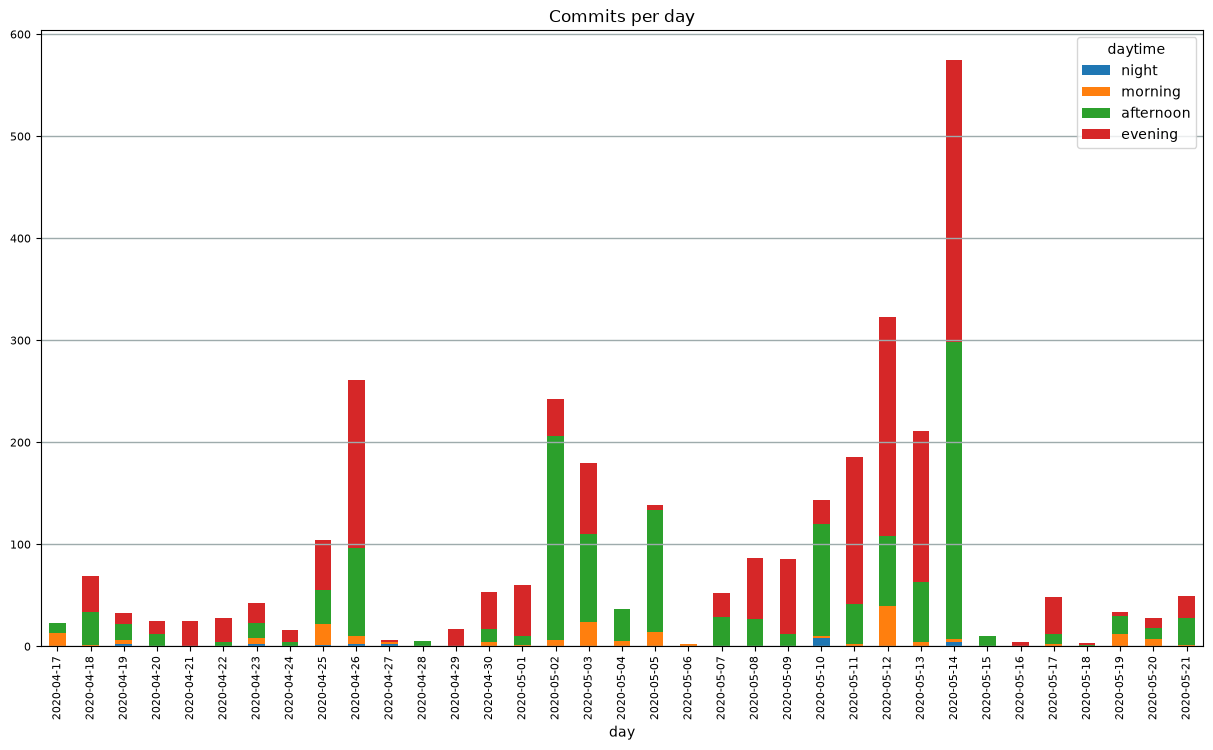

In [48]:
bar = pivot.plot(kind='bar', stacked=True, figsize=(15, 8), title="Commits per day", fontsize=8)
bar.grid(visible=True, axis='y', color="#9eabac", linestyle='-', linewidth=1)

<pre>
«Когда наши пользователи обычно коммитят: ночью, утром, днём или вечером?» — Днем и вечером
«Какой день имел максимальное число коммитов и при этом вечером коммитов больше, чем днём?»- 12 мая 2020 года
</pre>